# Notebook 2 — Watershed-Based Room Segmentation

**Stage 2 file · runs 2nd** (immediately after Notebook 1).


> **Pipeline execution order: `1 -> 2 -> 3 -> 4`.**
> The wall-assignment stage (Notebook 3) begins "obtain room mask `M_i`", and room masks
> are produced only by the watershed. The watershed therefore runs **before** wall
> assignment, so it is stage 2. Each notebook also loads what it needs from the previous
> stage's ZIP, so a stage can be re-run on its own as long as the stages it depends on have
> been run once.


## Purpose
Produce the geometric room-segmentation masks with the original deterministic
distance-transform watershed. **No algorithmic change** — the logic is moved into
`scan2bim.segment_rooms_watershed` and called here unchanged.

## Inputs  (from `stage1_occupancy.zip`)
- `wall_mask.npy` (or `wallness.npy` when `CFG.use_wallness=True`) — segmentation input.
- `coverage.npy` — for void rejection.
- `transform.json` — carried forward for downstream alignment.

## Outputs  (`{out_root}/stage2_watershed/`, zipped to `stage2_watershed.zip`)
- `room_labels.npy` — int32 labels: `-1` wall · `0` exterior · `>=1` rooms.
- `room_labels_color.png` — colourised labels for QA.
- `walls.npy` — the cleaned wall mask the watershed used (needed by Notebooks 3 & 4).
- `footprint.npy` — building footprint (needed by Notebook 4).
- `transform.json`, `config.json`.

## Assumptions
- Rasters were produced by Notebook 1 with the same `CFG` (pixel size, margins, etc.).

### Setup
**Run-All ready.** Edit **`params.yaml`** (the only config surface), then run every cell top
to bottom — no cell edits, ever. `load_config()` reads it over the `Config` defaults.

> **Skipped `pip install -e .`?** Prepend this 2-line path-shim to the cell below so
> `import scan2bim` resolves from `notebooks/methods/geometric/`:
> `import sys, os; sys.path.insert(0, os.path.abspath('../../..'))`

In [1]:
# ============================== scan2bim setup (local) ==============================
# One loader replaces the old ~30-line bootstrap and the per-notebook config cell. With
# `pip install -e .`, `import scan2bim` works from anywhere; `load_config()` reads
# params.yaml (the ONLY file you edit) over the Config defaults and resolves paths.
import os
import numpy as np
import scan2bim
from scan2bim import artifacts as A, viz

CFG = scan2bim.load_config()        # params.yaml over Config defaults; file_path/out_root -> abs
SHOW_DEBUG = True                   # set False to skip the QA plots
print('scan2bim', scan2bim.__version__, 'loaded from', os.path.dirname(scan2bim.__file__))
print('input cloud :', CFG.file_path, '| exists:', os.path.isfile(CFG.file_path))
print('output root :', CFG.out_root)

scan2bim 1.0.0 loaded from C:\onestruction\scan2bim
input cloud : C:\onestruction\data\area3.xyz | exists: True
output root : C:\onestruction\scan2bim_out


### Step 1 — Load the Stage-1 rasters

In [2]:
s1 = A.load_stage_dir(CFG.out_root, A.STAGE1)
scan2bim.assert_upstream_config(CFG, A.load_stage_config(s1))   # same cloud + grid as stage 1
wall_mask = A.load_npy(os.path.join(s1, A.WALLMASK_NPY)).astype(bool)
wallness  = A.load_npy(os.path.join(s1, A.WALLNESS_NPY)).astype(bool)
coverage  = A.load_npy(os.path.join(s1, A.COVERAGE_NPY)).astype(bool)
tf = A.load_transform(os.path.join(s1, A.TRANSFORM_JSON))

# Preserve the original segmentation-input choice (binary occupancy by default).
seg_input = wallness if CFG.use_wallness else wall_mask
print('segmentation input:', 'wallness' if CFG.use_wallness else 'wall_mask',
      '| shape', seg_input.shape)

segmentation input: wall_mask | shape (856, 1011)


### Step 2 — Run the watershed (unchanged algorithm)

In [3]:
labels, aux = scan2bim.segment_rooms_watershed(
    seg_input, CFG.pixel_m,
    marker_h_m=CFG.marker_h_m, footprint_close_m=CFG.footprint_close_m,
    merge_ridge_m=CFG.merge_ridge_m, min_room_area_m2=CFG.min_room_area_m2,
    min_wall_area_px=CFG.min_wall_area_px, door_seal_px=CFG.seal_gap_px,
    coverage=coverage, min_coverage_frac=CFG.min_coverage_frac, return_aux=True)
n_rooms = len([r for r in np.unique(labels) if r >= 1])
print('rooms found:', n_rooms)

rooms found: 32


### Optional — QA plots

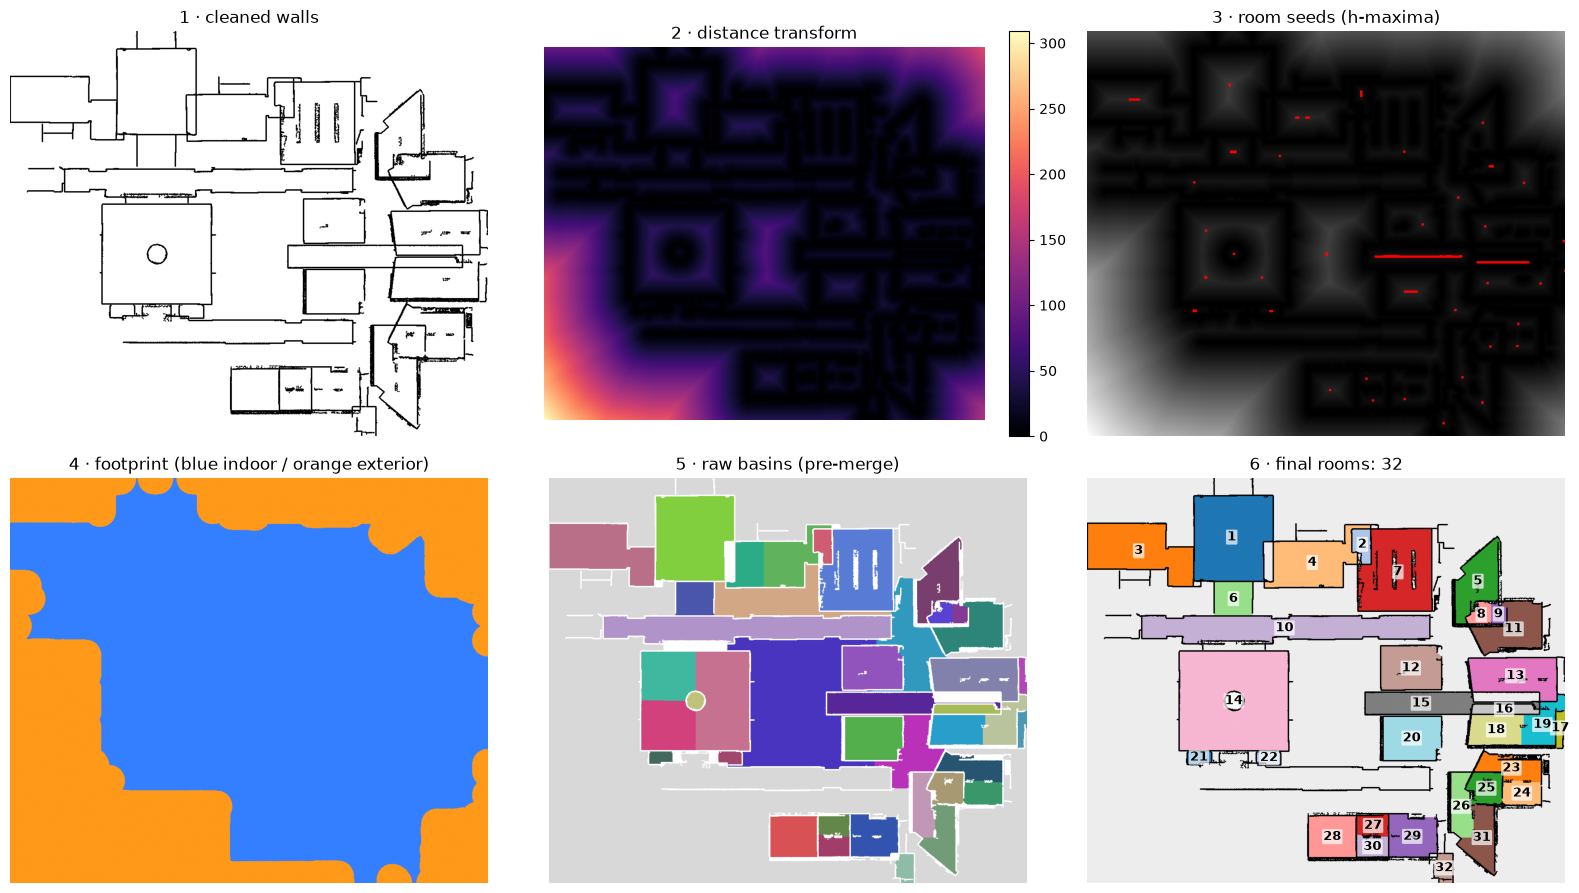

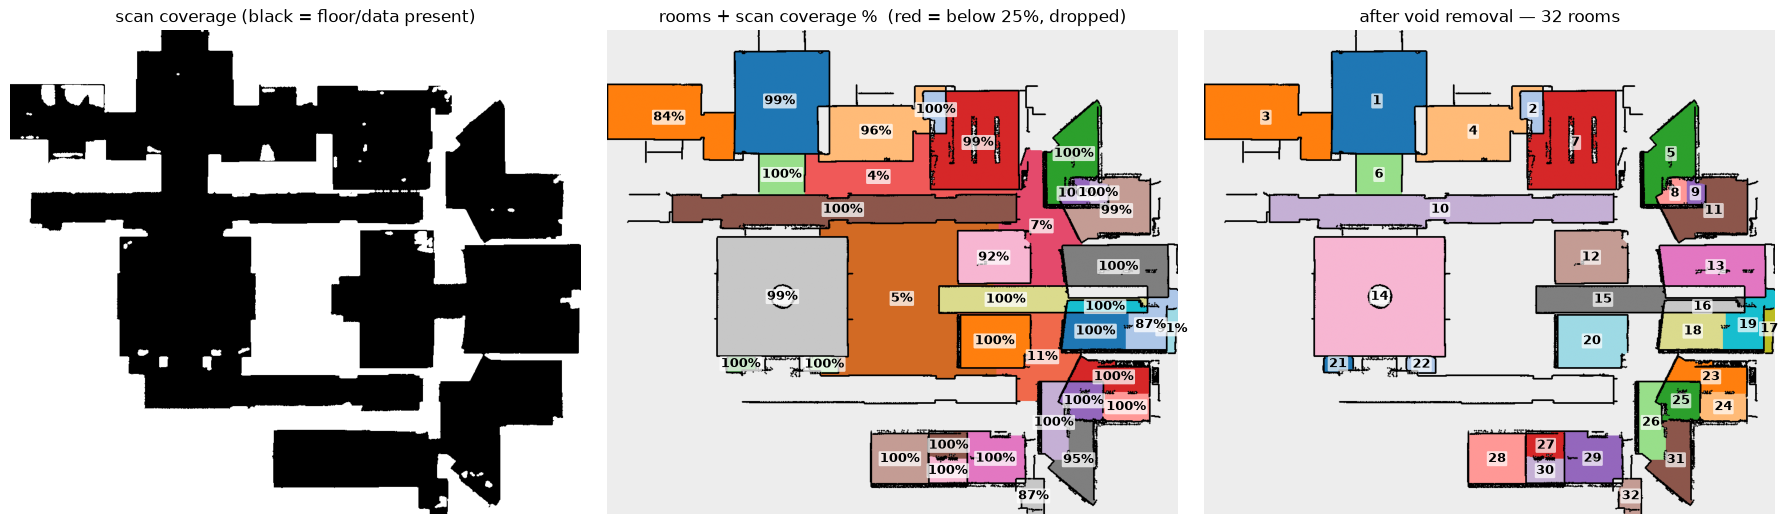

In [4]:
if SHOW_DEBUG:
    viz.show_watershed_internals(aux, labels, CFG.pixel_m)
    if aux.get('coverage') is not None:
        viz.show_coverage_debug(aux, labels, CFG)

### Step 3 — Save outputs and package the ZIP

In [5]:
out_dir = A.ensure_dir(A.stage_dir(CFG.out_root, A.STAGE2))
A.save_npy(os.path.join(out_dir, A.ROOM_LABELS_NPY), labels.astype('int32'))
A.save_label_png(os.path.join(out_dir, A.ROOM_LABELS_PNG), labels)
A.save_npy(os.path.join(out_dir, A.WATERSHED_WALLS_NPY), aux['walls'].astype(bool))
A.save_npy(os.path.join(out_dir, A.FOOTPRINT_NPY), aux['footprint'].astype(bool))
# carry the transform forward unchanged
A.save_transform(os.path.join(out_dir, A.TRANSFORM_JSON), tf)
A.save_config(os.path.join(out_dir, A.CONFIG_JSON), CFG)
zip_path = A.package_stage(CFG.out_root, A.STAGE2)
print('packaged ->', zip_path)

packaged -> C:\onestruction\scan2bim_out\stage2_watershed.zip
